**NAME** CHENCHIRA BAMRUNG
**ID** 6210550371

In [ ]:
#! pip install kaggle

In [ ]:
#Need to upload file in session storage
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! kaggle datasets download andradaolteanu/gtzan-dataset-music-genre-classification

gtzan-dataset-music-genre-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
! unzip gtzan-dataset-music-genre-classification

Archive:  gtzan-dataset-music-genre-classification.zip
replace Data/features_30_sec.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#import libraly
import math
import json
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

**PROCESS**
1. Crete a function to do the augmentation on audio file. (Pitch Change and Add noise)
2. Extract MFCC on original signal and augmented signal
3. Train-Test-Validate Split
4. Build the CNN Model
5. Train the Model
6. Evaluate model with testing set



In [ ]:
dataset_path = '/content/Data/genres_original'
SAMPLE_RATE = 22050
DURATION = 30
sample_per_song = SAMPLE_RATE*DURATION

In [ ]:
import os
from sklearn.model_selection import train_test_split

# List all audio file paths
audio_files = []
genre = []

for dirpath, dirnames, filenames in os.walk(dataset_path):
    for filename in filenames:
        if filename.endswith(".wav"):
          #print("filename", filename)
          audio_files.append(os.path.join(dirpath, filename))
            #We are in subfolder now

    if dirpath is not dataset_path:
      pathname_split = dirpath.split("/")  #pathname => /content/Data/genres_original/reggae, gonna split it
      genre_name = pathname_split[-1]
      genre.append(genre_name)
      print(genre_name)

pop
hiphop
disco
country
blues
jazz
reggae
classical
metal
rock


In [ ]:
#Train Test Split the file
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(audio_files, test_size=0.2)
train_set, validation_set = train_test_split(train_set, test_size=0.2)

In [ ]:
len(train_set)

640

In [ ]:
len(validation_set)

160

In [ ]:
len(test_set)

200

In [ ]:
def augment_signal(sample, sr):

  # 2 pitch
  for n_steps in [4,6]:
    signal_pitch = librosa.effects.pitch_shift(y=sample, sr=SAMPLE_RATE, n_steps=5)

  wn = np.random.randn(len(sample))
  signal_noise = sample + 0.005*wn

  return signal_pitch, signal_noise,

In [ ]:
def training_mfccs(dataset_path, n_mfcc, n_fft, hop_length, num_segments):

    data_dict = {
        "mfcc": [],
        "labels": [],
    }

    sample_per_seg = int(sample_per_song/num_segments)
    expected_mfcc = math.ceil(sample_per_seg/hop_length)

    for file_path in dataset_path:
      #print(file_path)
      if file_path == '/content/Data/genres_original/jazz/jazz.00054.wav':
        print('skip this file due to some problem i cannot fix')
        pass
      else:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        #Pass to Augment
        signal_pitch, signal_noise = augment_signal(signal, sr)

        for s in range(num_segments):
          start_sample = sample_per_seg*s
          finish_sample = start_sample + sample_per_seg
          mfcc_sl = librosa.feature.mfcc(y=signal[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_sl = mfcc_sl.T
          mfcc_pitch = librosa.feature.mfcc(y=signal_pitch[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_pitch = mfcc_pitch.T
          mfcc_noise = librosa.feature.mfcc(y=signal_noise[start_sample:finish_sample], sr=SAMPLE_RATE, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
          mfcc_noise = mfcc_noise.T

          if len(mfcc_sl) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_sl.tolist())
          if len(mfcc_pitch) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_pitch.tolist())
          if len(mfcc_noise) == expected_mfcc:
            data_dict["mfcc"].append(mfcc_noise.tolist())

            for u in range(len(genre)):
              split =  file_path.split("/")
              #print(split)
              if split[4] == genre[u]:
                for z in range(0,3):
                  data_dict["labels"].append(int(u))

    return data_dict


In [ ]:
import librosa
import math
import numpy as np

def training_mel_spectrograms(dataset_path, n_mels, n_fft, hop_length, num_segments):

    data_dict = {
        "mel_spectrogram": [],
        "labels": [],
    }

    sample_per_seg = int(sample_per_song / num_segments)
    expected_frames = math.ceil(sample_per_seg / hop_length)

    for file_path in dataset_path:
        if file_path == '/content/Data/genres_original/jazz/jazz.00054.wav':
            print('Skipping file:', file_path, 'due to some problem that cannot be fixed')
        else:
            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            #Pass to Augment
            signal_pitch, signal_noise = augment_signal(signal, sr)

            for s in range(num_segments):
                start_sample = sample_per_seg * s
                finish_sample = start_sample + sample_per_seg
                mel_spectrogram = librosa.feature.melspectrogram(y=signal[start_sample:finish_sample], sr=SAMPLE_RATE, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
                p_mel_spectrogram = librosa.feature.melspectrogram(y=signal_pitch[start_sample:finish_sample], sr=SAMPLE_RATE, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                p_mel_spectrogram_db = librosa.power_to_db(p_mel_spectrogram, ref=np.max)
                n_mel_spectrogram = librosa.feature.melspectrogram(y=signal_noise[start_sample:finish_sample], sr=SAMPLE_RATE, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                n_mel_spectrogram_db = librosa.power_to_db(n_mel_spectrogram, ref=np.max)

                num_frames = mel_spectrogram_db.shape[1]
                p_num_frames = p_mel_spectrogram_db.shape[1]
                n_num_frames = n_mel_spectrogram_db.shape[1]

                if num_frames == expected_frames:
                    data_dict["mel_spectrogram"].append(mel_spectrogram_db.tolist())
                if p_num_frames == expected_frames:
                    data_dict["mel_spectrogram"].append(p_mel_spectrogram_db.tolist())
                if n_num_frames == expected_frames:
                    data_dict["mel_spectrogram"].append(n_mel_spectrogram_db.tolist())

                    for u in range(len(genre)):
                        split = file_path.split("/")
                        if split[4] == genre[u]:
                          for z in range(0,3):
                            data_dict["labels"].append(int(u))

    return data_dict


In [ ]:
import librosa
import math
import numpy as np

def testing_mel_spectrograms(dataset_path, n_mels, n_fft, hop_length, num_segments):

    data_dict = {
        "mel_spectrogram": [],
        "labels": [],
    }

    sample_per_seg = int(sample_per_song / num_segments)
    expected_frames = math.ceil(sample_per_seg / hop_length)

    for file_path in dataset_path:
        if file_path == '/content/Data/genres_original/jazz/jazz.00054.wav':
            print('Skipping file:', file_path, 'due to some problem that cannot be fixed')
        else:
            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

            for s in range(num_segments):
                start_sample = sample_per_seg * s
                finish_sample = start_sample + sample_per_seg
                mel_spectrogram = librosa.feature.melspectrogram(y=signal[start_sample:finish_sample], sr=SAMPLE_RATE, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
                num_frames = mel_spectrogram_db.shape[1]

                if num_frames == expected_frames:
                    data_dict["mel_spectrogram"].append(mel_spectrogram_db.tolist())

                    for u in range(len(genre)):
                        split = file_path.split("/")
                        if split[4] == genre[u]:
                            data_dict["labels"].append(int(u))

    return data_dict


In [ ]:
x_train_dict = training_mel_spectrograms(train_set, n_mels = 64, n_fft=2048, hop_length=512, num_segments=10)

Skipping file: /content/Data/genres_original/jazz/jazz.00054.wav due to some problem that cannot be fixed


In [ ]:
x_valid_dict = testing_mel_spectrograms(validation_set, n_mels = 64, n_fft=2048, hop_length=512, num_segments=10)

In [ ]:
x_test_dict = testing_mel_spectrograms(test_set, n_mels = 64, n_fft=2048, hop_length=512, num_segments=10)

In [ ]:
#x_train_dict = training_mfccs(train_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)
#x_train_dict = training_mfccs(train_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)
#x_valid_dict = testing_mfccs(validation_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)
#x_test_dict = testing_mfccs(test_set, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10)

In [ ]:
#Declare Input and Label to NN
#mfcc_inputs = np.array(x_train_dict["mfcc"])
#targets = np.array(x_train_dict["labels"])

x_train = np.array(x_train_dict["mel_spectrogram"])
y_train = np.array(x_train_dict["labels"])
x_validation = np.array(x_valid_dict["mel_spectrogram"])
y_validation = np.array(x_valid_dict["labels"])
x_test = np.array(x_test_dict["mel_spectrogram"])
y_test = np.array(x_test_dict["labels"])

#Normalize training set
train_min = np.min(x_train)
train_max = np.max(x_train)
x_train = (x_train - train_min) / (train_max - train_min)
x_validation = (x_validation - train_min) / (train_max - train_min)
x_test = (x_test - train_min) / (train_max - train_min)

#Since input shape of CNN need to be 4d array
#Change shape to (num_samples, num_time_bin, mfcc_value, 1)
x_train = x_train[:,:,:, np.newaxis]
x_validation = x_validation[:,:,:, np.newaxis]
x_test = x_test[:,:,:, np.newaxis]

#Declare Input Shape
input_shape = (x_train.shape[1], x_train.shape[2], x_train.shape[3])

In [ ]:
x_train.shape

(19161, 64, 130, 1)

In [ ]:
input_shape

(64, 130, 1)

In [ ]:
y_train.shape

(19161,)

**MODEL IMPLEMENTATION**
After built the model, train it with training set and evaluate with validation set. Tuning model and retrain until got the satisfy result

In [ ]:
from tensorflow import keras
from keras.layers import Activation, Dense, Flatten, Dropout
#from keras.models import Sequential
from keras import layers
from keras import models, Sequential

def CNN_model(input_shape):

  model = Sequential()

  #1st layer
  model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape = input_shape))
  model.add(layers.MaxPooling2D((3, 3), strides = (3,3), padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(Dropout(0.2))

  #2nd layer
  model.add(layers.Conv2D(32, (3, 3), activation='relu'))
  model.add(layers.MaxPooling2D((3, 3), strides = (3,3), padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(Dropout(0.2))

  #3rd layer
  model.add(layers.Conv2D(32, (2, 2), activation='relu'))
  model.add(layers.MaxPooling2D((2, 2), strides = (3,3), padding = 'same'))
  model.add(layers.BatchNormalization())
  model.add(Dropout(0.4))

  #Flatten to 1D
  model.add(layers.Flatten())
  #model.add(layers.Dense(120, activation='relu'))
  #model.add(layers.BatchNormalization())
  #model.add(Dropout(0.2))
  model.add(layers.Dense(32, activation='relu'))
  model.add(layers.BatchNormalization())
  model.add(Dropout(0.4))

  #Output
  model.add(layers.Dense(10, activation='softmax'))

  # compile model
  model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

  return model

In [ ]:
CNN_model = CNN_model(input_shape)
CNN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 128, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 21, 43, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 21, 43, 32)       128       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 21, 43, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 19, 41, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 14, 32)        0

In [ ]:
#Train the model
trained = CNN_model.fit(x_train, y_train, validation_data = (x_validation, y_validation), epochs = 30, batch_size = 32, verbose = 2)

Epoch 1/30
599/599 - 129s - loss: 2.7725 - accuracy: 0.1530 - val_loss: 2.3624 - val_accuracy: 0.1625 - 129s/epoch - 215ms/step
Epoch 2/30
599/599 - 126s - loss: 2.3623 - accuracy: 0.2207 - val_loss: 1.8727 - val_accuracy: 0.3156 - 126s/epoch - 210ms/step
Epoch 3/30
599/599 - 126s - loss: 2.0965 - accuracy: 0.2724 - val_loss: 1.9331 - val_accuracy: 0.3075 - 126s/epoch - 211ms/step
Epoch 4/30
599/599 - 126s - loss: 1.9373 - accuracy: 0.3127 - val_loss: 1.7596 - val_accuracy: 0.3512 - 126s/epoch - 211ms/step
Epoch 5/30
599/599 - 126s - loss: 1.8355 - accuracy: 0.3432 - val_loss: 1.7720 - val_accuracy: 0.3688 - 126s/epoch - 211ms/step
Epoch 6/30
599/599 - 128s - loss: 1.7523 - accuracy: 0.3672 - val_loss: 1.8341 - val_accuracy: 0.3738 - 128s/epoch - 214ms/step
Epoch 7/30
599/599 - 130s - loss: 1.6959 - accuracy: 0.3835 - val_loss: 1.7408 - val_accuracy: 0.3869 - 130s/epoch - 216ms/step
Epoch 8/30
599/599 - 131s - loss: 1.6310 - accuracy: 0.4107 - val_loss: 2.0375 - val_accuracy: 0.3281 - 

In [ ]:
#Evaluate
test_err, test_acc = CNN_model.evaluate(x_test, y_test, verbose = 2)
print("Accuracy on testing set is", test_acc)


63/63 - 13s - loss: 1.1927 - accuracy: 0.6088 - 13s/epoch - 213ms/step
Accuracy on testing set is 0.6088044047355652


<Figure size 640x480 with 0 Axes>

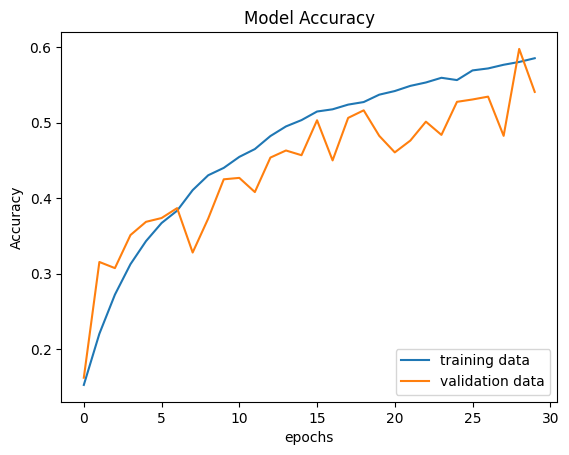

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.plot(trained.history['accuracy'])
plt.plot(trained.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('epochs')
plt.legend(['training data', 'validation data'], loc = 'lower right')
plt.figure()
#plt.show()

<Figure size 640x480 with 0 Axes>

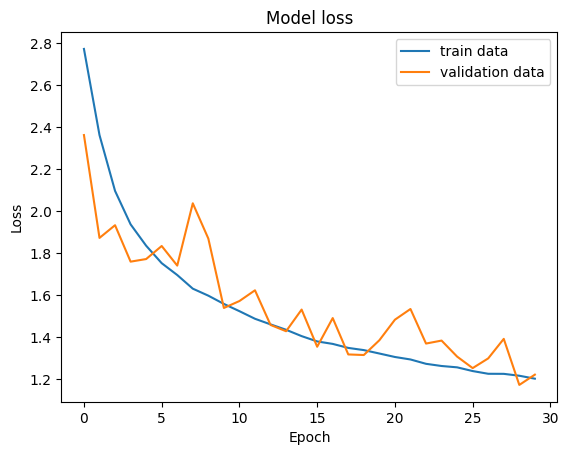

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train data', 'validation data'], loc='upper right')
#plt.legend()

plt.figure()